In [1]:
import cv2
import mediapipe
import numpy
import pandas
import sklearn

print("All libraries are working!")

All libraries are working!


In [2]:
import cv2

cap = cv2.VideoCapture(0)

while True:
    ret, frame = cap.read()

    if not ret:
        print("Could not access webcam")
        break

    cv2.imshow("Webcam Test", frame)

    # Press ESC to stop
    if cv2.waitKey(1) % 256 == 27:
        break

cap.release()
cv2.destroyAllWindows()

In [3]:
import cv2
import mediapipe as mp

# Initialize MediaPipe Pose
mp_pose = mp.solutions.pose
mp_drawing = mp.solutions.drawing_utils

pose = mp_pose.Pose(
    static_image_mode=False,
    model_complexity=1,
    min_detection_confidence=0.5,
    min_tracking_confidence=0.5
)

# Start webcam
cap = cv2.VideoCapture(0)

while True:
    ret, frame = cap.read()

    if not ret:
        print("Could not access webcam")
        break

    # Convert BGR → RGB
    rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    # Detect body pose
    results = pose.process(rgb_frame)

    # Draw body landmarks
    if results.pose_landmarks:
        mp_drawing.draw_landmarks(
            frame,
            results.pose_landmarks,
            mp_pose.POSE_CONNECTIONS
        )

    cv2.imshow("AI Posture Detection", frame)

    # ESC to exit
    if cv2.waitKey(1) % 256 == 27:
        break

cap.release()
cv2.destroyAllWindows()
pose.close()

AttributeError: module 'mediapipe' has no attribute 'solutions'

In [4]:
import mediapipe as mp

print(mp.__version__)
print(mp.__file__)

1.0.1
c:\Users\garga\AppData\Local\Programs\Python\Python313\Lib\site-packages\mediapipe\__init__.py


In [5]:
%pip install ultralytics

   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 1.5/1.5 MB 23.7 MB/s  0:00:00
   ---------------------------------------- 0.0/865.8 kB ? eta -:--:--
   ---------------------------------------- 865.8/865.8 kB 22.5 MB/s  0:00:00
   ---------------------------------------- 0.0/51.3 MB ? eta -:--:--
   ----- ---------------------------------- 7.1/51.3 MB 34.7 MB/s eta 0:00:02
   ----------- ---------------------------- 14.7/51.3 MB 34.0 MB/s eta 0:00:02
   --------------- ------------------------ 19.9/51.3 MB 30.7 MB/s eta 0:00:02
   ---------------- ----------------------- 21.8/51.3 MB 25.5 MB/s eta 0:00:02
   ------------------ --------------------- 23.9/51.3 MB 22.3 MB/s eta 0:00:02
   -------------------- ------------------- 25.7/51.3 MB 20.3 MB/s eta 0:00:02
   --------------------- ------------------ 27.8/51.3 MB 18.6 MB/s eta 0:00:02
   ----------------------- ---------------- 29.6/51.3 MB 17.2 MB/s eta 0:00:02
   ----


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
from ultralytics import YOLO

print("YOLO is working!")

Creating new Ultralytics Settings v0.0.8 file  
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\garga\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
YOLO is working!


In [7]:
from ultralytics import YOLO

model = YOLO("yolo11n-pose.pt")

print("Pose model loaded!")

Pose model loaded!


In [8]:
import cv2

cap = cv2.VideoCapture(0)

while True:
    ret, frame = cap.read()

    if not ret:
        print("Could not access webcam")
        break

    # Run YOLO pose detection
    results = model(frame, verbose=False)

    # Draw pose/keypoints on the frame
    annotated_frame = results[0].plot()

    cv2.imshow("AI Posture Detection", annotated_frame)

    # Press ESC to exit
    if cv2.waitKey(1) % 256 == 27:
        break

cap.release()
cv2.destroyAllWindows()

In [9]:
import cv2

cap = cv2.VideoCapture(0)

while True:
    ret, frame = cap.read()

    if not ret:
        print("Could not access webcam")
        break

    # Run YOLO pose detection
    results = model(frame, verbose=False)

    # Draw detected pose on the frame
    annotated_frame = results[0].plot()

    cv2.imshow("AI Posture Detector", annotated_frame)

    # Press ESC to exit
    if cv2.waitKey(1) % 256 == 27:
        break

cap.release()
cv2.destroyAllWindows()

In [10]:
import cv2

cap = cv2.VideoCapture(0)

ret, frame = cap.read()

cap.release()

if ret:
    results = model(frame, verbose=False)

    print("Number of people detected:", len(results[0].keypoints))

Number of people detected: 1


In [11]:
if ret and len(results[0].keypoints) > 0:

    keypoints = results[0].keypoints.xy[0].cpu().numpy()

    print("Keypoints shape:", keypoints.shape)
    print(keypoints)

Keypoints shape: (17, 2)
[[     391.18      179.49]
 [     440.83      146.45]
 [     358.15      117.35]
 [     479.45      192.23]
 [     283.42      131.88]
 [     542.53      404.88]
 [     119.11      386.85]
 [     588.92         480]
 [     76.554         480]
 [     517.64      449.72]
 [     180.49      464.37]
 [     443.42         480]
 [     183.69         480]
 [     471.62      401.21]
 [     229.42      394.74]
 [        353      476.43]
 [     343.54      423.31]]


In [12]:
import math
import numpy as np

def calculate_angle(a, b, c):
    """
    Calculate angle ABC using three points.
    """
    a = np.array(a)
    b = np.array(b)
    c = np.array(c)

    radians = np.arctan2(c[1] - b[1], c[0] - b[0]) - \
              np.arctan2(a[1] - b[1], a[0] - b[0])

    angle = np.abs(radians * 180.0 / np.pi)

    if angle > 180:
        angle = 360 - angle

    return angle

In [13]:
# Get important body keypoints

nose = keypoints[0]

left_shoulder = keypoints[5]
right_shoulder = keypoints[6]

left_hip = keypoints[11]
right_hip = keypoints[12]

print("Nose:", nose)
print("Left Shoulder:", left_shoulder)
print("Right Shoulder:", right_shoulder)
print("Left Hip:", left_hip)
print("Right Hip:", right_hip)

Nose: [     391.18      179.49]
Left Shoulder: [     542.53      404.88]
Right Shoulder: [     119.11      386.85]
Left Hip: [     443.42         480]
Right Hip: [     183.69         480]


In [14]:
shoulder_angle = calculate_angle(
    left_shoulder,
    nose,
    right_shoulder
)

print("Shoulder angle:", shoulder_angle)

Shoulder angle: 86.56773


In [15]:
mid_shoulder = (
    (left_shoulder[0] + right_shoulder[0]) / 2,
    (left_shoulder[1] + right_shoulder[1]) / 2
)

mid_hip = (
    (left_hip[0] + right_hip[0]) / 2,
    (left_hip[1] + right_hip[1]) / 2
)

dx = mid_shoulder[0] - mid_hip[0]
dy = mid_shoulder[1] - mid_hip[1]

torso_angle = math.degrees(math.atan2(abs(dx), abs(dy)))

print("Torso angle:", torso_angle)

Torso angle: 11.597816159237388


In [16]:
import cv2
import pandas as pd
import numpy as np
import math
import time

# Store collected data here
data = []

print("Dataset collector ready!")

Dataset collector ready!


In [17]:
def extract_features(keypoints):
    
    # Important points
    nose = keypoints[0]
    
    left_shoulder = keypoints[5]
    right_shoulder = keypoints[6]
    
    left_hip = keypoints[11]
    right_hip = keypoints[12]

    # Middle of shoulders
    mid_shoulder = np.array([
        (left_shoulder[0] + right_shoulder[0]) / 2,
        (left_shoulder[1] + right_shoulder[1]) / 2
    ])

    # Middle of hips
    mid_hip = np.array([
        (left_hip[0] + right_hip[0]) / 2,
        (left_hip[1] + right_hip[1]) / 2
    ])

    # Shoulder angle
    shoulder_angle = calculate_angle(
        left_shoulder,
        nose,
        right_shoulder
    )

    # Torso angle
    dx = mid_shoulder[0] - mid_hip[0]
    dy = mid_shoulder[1] - mid_hip[1]

    torso_angle = math.degrees(
        math.atan2(abs(dx), abs(dy))
    )

    # Shoulder width
    shoulder_width = np.linalg.norm(
        left_shoulder - right_shoulder
    )

    # Hip width
    hip_width = np.linalg.norm(
        left_hip - right_hip
    )

    # Distance between shoulders and hips
    torso_length = np.linalg.norm(
        mid_shoulder - mid_hip
    )

    return [
        shoulder_angle,
        torso_angle,
        shoulder_width,
        hip_width,
        torso_length
    ]

In [18]:
data = []

cap = cv2.VideoCapture(0)

print("Sit in GOOD POSTURE.")
print("Collecting data in 3 seconds...")

time.sleep(3)

while True:

    ret, frame = cap.read()

    if not ret:
        break

    results = model(frame, verbose=False)

    if len(results[0].keypoints) > 0:

        keypoints = results[0].keypoints.xy[0].cpu().numpy()

        features = extract_features(keypoints)

        # 0 = Good posture
        data.append(features + [0])

        cv2.putText(
            frame,
            "GOOD POSTURE - COLLECTING",
            (20, 40),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.8,
            (0, 255, 0),
            2
        )

    cv2.imshow("Collect Good Posture", frame)

    # Press G to stop
    if cv2.waitKey(1) & 0xFF == ord('g'):
        break

cap.release()
cv2.destroyAllWindows()

print("Good posture samples collected:", len(data))

Sit in GOOD POSTURE.


KeyboardInterrupt: 

In [19]:
try:
    cap.release()
except:
    pass

cv2.destroyAllWindows()

In [20]:
# Test faster YOLO inference

import cv2
import time

cap = cv2.VideoCapture(0)

ret, frame = cap.read()

if ret:
    start = time.time()

    results = model(
        frame,
        imgsz=320,
        conf=0.5,
        verbose=False
    )

    end = time.time()

    print("Inference time:", round(end - start, 2), "seconds")
    
cap.release()
cv2.destroyAllWindows()

Inference time: 0.21 seconds


In [21]:
import cv2
import time

# Start with an empty dataset
data = []

cap = cv2.VideoCapture(0)

print("Sit in GOOD POSTURE.")
print("Starting in 3 seconds...")

time.sleep(3)

start_time = time.time()
last_sample_time = 0
duration = 30
sample_interval = 0.5

while time.time() - start_time < duration:

    ret, frame = cap.read()

    if not ret:
        break

    current_time = time.time()

    # Only run YOLO every 0.5 seconds
    if current_time - last_sample_time >= sample_interval:

        results = model(
            frame,
            imgsz=320,
            conf=0.5,
            verbose=False
        )

        if len(results[0].keypoints) > 0:

            keypoints = results[0].keypoints.xy[0].cpu().numpy()

            # Make sure we have all 17 keypoints
            if keypoints.shape == (17, 2):

                features = extract_features(keypoints)

                # 0 = Good posture
                data.append(features + [0])

                last_sample_time = current_time

    # Show remaining time
    remaining = int(duration - (current_time - start_time))

    cv2.putText(
        frame,
        f"GOOD POSTURE | Time: {remaining}s",
        (20, 40),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (0, 255, 0),
        2
    )

    cv2.imshow("Collecting Good Posture", frame)

    # Keep window responsive
    cv2.waitKey(1)

cap.release()
cv2.destroyAllWindows()

print("Good posture samples:", len(data))

Sit in GOOD POSTURE.
Starting in 3 seconds...
Good posture samples: 57


In [22]:
cap = cv2.VideoCapture(0)

print("Now sit in BAD / SLOUCHED POSTURE.")
print("Starting in 3 seconds...")

time.sleep(3)

start_time = time.time()
last_sample_time = 0
duration = 30
sample_interval = 0.5

while time.time() - start_time < duration:

    ret, frame = cap.read()

    if not ret:
        break

    current_time = time.time()

    if current_time - last_sample_time >= sample_interval:

        results = model(
            frame,
            imgsz=320,
            conf=0.5,
            verbose=False
        )

        if len(results[0].keypoints) > 0:

            keypoints = results[0].keypoints.xy[0].cpu().numpy()

            if keypoints.shape == (17, 2):

                features = extract_features(keypoints)

                # 1 = Bad posture
                data.append(features + [1])

                last_sample_time = current_time

    remaining = int(duration - (current_time - start_time))

    cv2.putText(
        frame,
        f"BAD POSTURE | Time: {remaining}s",
        (20, 40),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (0, 0, 255),
        2
    )

    cv2.imshow("Collecting Bad Posture", frame)

    cv2.waitKey(1)

cap.release()
cv2.destroyAllWindows()

print("Total samples:", len(data))

Now sit in BAD / SLOUCHED POSTURE.
Starting in 3 seconds...
Total samples: 113


In [23]:
columns = [
    "shoulder_angle",
    "torso_angle",
    "shoulder_width",
    "hip_width",
    "torso_length",
    "posture"
]

df = pd.DataFrame(data, columns=columns)

print(df.shape)
print()
print(df["posture"].value_counts())

(113, 6)

posture
0    57
1    56
Name: count, dtype: int64


In [24]:
df.to_csv("posture_data.csv", index=False)

print("posture_data.csv saved!")

posture_data.csv saved!


In [25]:
df.head()
df["posture"].value_counts()

posture
0    57
1    56
Name: count, dtype: int64

In [26]:
X = df[
    [
        "shoulder_angle",
        "torso_angle",
        "shoulder_width",
        "hip_width",
        "torso_length"
    ]
]

y = df["posture"]

print("Features shape:", X.shape)
print("Labels shape:", y.shape)

Features shape: (113, 5)
Labels shape: (113,)


In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 90
Testing samples: 23


In [28]:
from sklearn.tree import DecisionTreeClassifier

classifier = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

classifier.fit(X_train, y_train)

print("Decision Tree trained successfully!")

Decision Tree trained successfully!


In [29]:
from sklearn.metrics import accuracy_score

y_pred = classifier.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", round(accuracy * 100, 2), "%")

Model Accuracy: 100.0 %


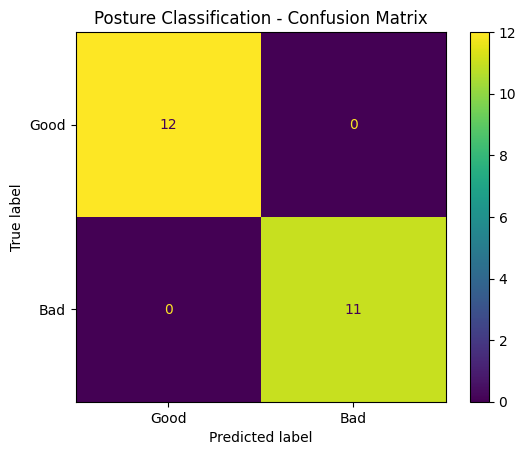

In [30]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Good", "Bad"]
)

disp.plot()
plt.title("Posture Classification - Confusion Matrix")
plt.show()

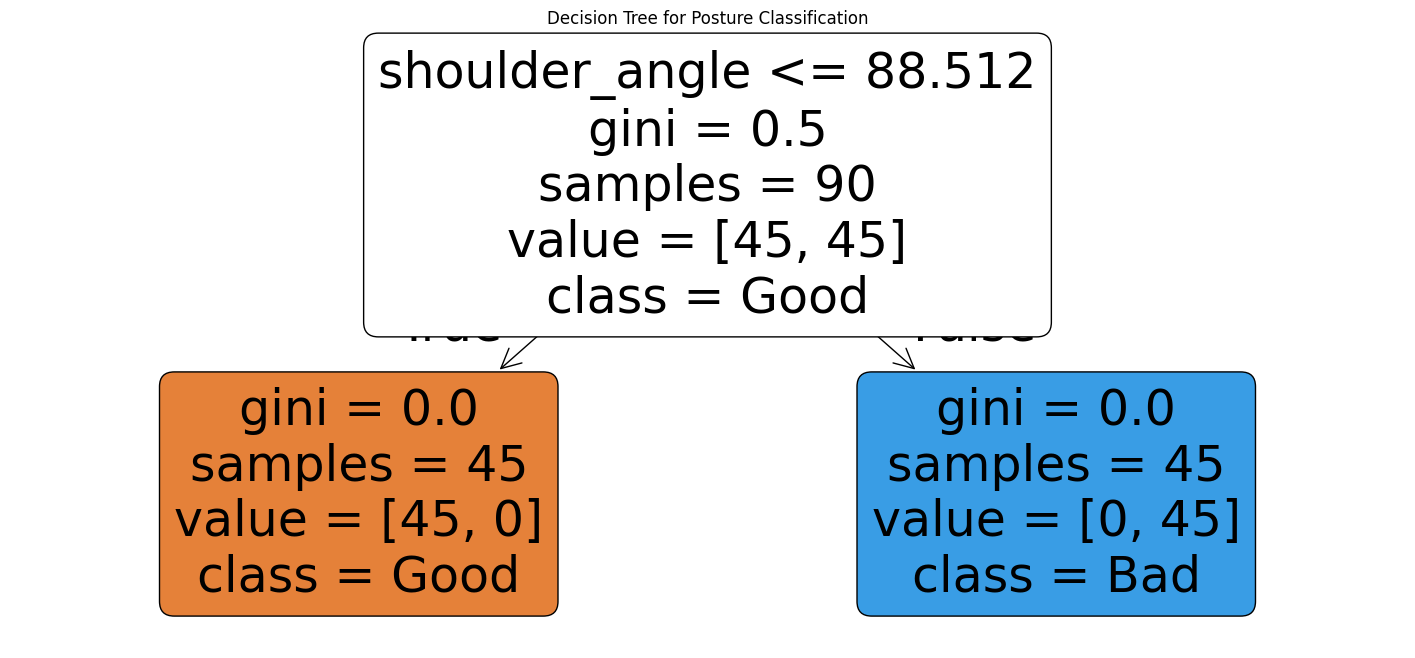

In [31]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 8))

plot_tree(
    classifier,
    feature_names=X.columns,
    class_names=["Good", "Bad"],
    filled=True,
    rounded=True
)

plt.title("Decision Tree for Posture Classification")
plt.show()

In [32]:
import joblib

joblib.dump(classifier, "posture_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [33]:
import cv2
import numpy as np
import time

cap = cv2.VideoCapture(0)

# Make webcam window a reasonable size
cap.set(cv2.CAP_PROP_FRAME_WIDTH, 640)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 480)

print("Starting AI Posture Detector...")
print("Press ESC to stop.")

while True:

    ret, frame = cap.read()

    if not ret:
        print("Could not access webcam")
        break

    # YOLO pose detection
    results = model(
        frame,
        imgsz=320,
        conf=0.5,
        verbose=False
    )

    # Draw YOLO pose
    annotated_frame = results[0].plot()

    # Check if a person was detected
    if len(results[0].keypoints) > 0:

        keypoints = results[0].keypoints.xy[0].cpu().numpy()

        # Make sure all 17 keypoints exist
        if keypoints.shape == (17, 2):

            # Extract the same features used during training
            features = extract_features(keypoints)

            # Convert features into DataFrame
            feature_df = pd.DataFrame(
                [features],
                columns=[
                    "shoulder_angle",
                    "torso_angle",
                    "shoulder_width",
                    "hip_width",
                    "torso_length"
                ]
            )

            # Predict posture
            prediction = classifier.predict(feature_df)[0]

            # Prediction probability
            probabilities = classifier.predict_proba(feature_df)[0]
            confidence = max(probabilities) * 100

            # Good = 0, Bad = 1
            if prediction == 0:
                label = "GOOD POSTURE"
                text_color = (0, 255, 0)
            else:
                label = "BAD POSTURE"
                text_color = (0, 0, 255)

            # Display result
            cv2.rectangle(
                annotated_frame,
                (10, 10),
                (360, 90),
                (0, 0, 0),
                -1
            )

            cv2.putText(
                annotated_frame,
                label,
                (25, 45),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.9,
                text_color,
                2
            )

            cv2.putText(
                annotated_frame,
                f"Confidence: {confidence:.1f}%",
                (25, 75),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6,
                (255, 255, 255),
                2
            )

    else:

        cv2.putText(
            annotated_frame,
            "NO PERSON DETECTED",
            (20, 40),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.8,
            (0, 0, 255),
            2
        )

    # Show final output
    cv2.imshow(
        "AI Posture Detector",
        annotated_frame
    )

    # ESC to exit
    if cv2.waitKey(1) % 256 == 27:
        break

cap.release()
cv2.destroyAllWindows()

Starting AI Posture Detector...
Press ESC to stop.
